# <center> **Tarea 1** </center>

1. Proponer entre 4 y 5 distribuciones de probabilidad para modelar los datos de una variable seleccionada.
2. Para cada distribución, realizar las siguientes gráficas:
   - **QQ-Plot:** Comparar los cuantiles teóricos y empíricos.
   - **PP-Plot:** Comparar la función de distribución acumulada (CDF) teórica y empírica.
   - **Contraste entre densidades:** Graficar la densidad teórica superpuesta a la densidad empírica.
   - **Contraste entre CDF:** Comparar la función de distribución acumulada teórica y empírica.
3. Determinar la distribución que mejor se ajuste a los datos utilizando el p-valor del test de Kolmogorov-Smirnov.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
import numpy as np
import pandas as pd

In [2]:
data = df = pd.read_csv('../Dataset/data_aula04.csv', header=0, sep=';')
print(data.head())

   var1       var2      var3   var4     var5
0     2   0.031616  3.809430   6.09   7200.0
1     2  -0.000553  3.697720  12.46   7200.0
2     3   0.058933  3.879095  17.79  72800.0
3     2   0.000243  3.793765  32.07  16800.0
4     1  82.699796  3.969103  30.31  84800.0


In [3]:
def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

In [4]:

# Función para graficar el contraste entre las distribuciones
def plot_distribution_comparison(data, dist_name, ax_row):
    dist = getattr(sps, dist_name)
    
    # Ajuste de la distribución
    params = dist.fit(data)
    
    # QQ-Plot
    ax_row[0].cla()
    sps.probplot(data, dist=dist_name, sparams=params, plot=ax_row[0])
    ax_row[0].set_title(f'QQ-Plot ({dist_name})')
    
    # PP-Plot
    x_empirical, y_empirical = ecdf(data)
    y_theoretical = dist.cdf(x_empirical, *params)
    
    ax_row[1].cla()
    ax_row[1].plot(x_empirical, y_empirical, label='Empirical CDF')
    ax_row[1].plot(x_empirical, y_theoretical, label=f'Theoretical CDF ({dist_name})', linestyle='--')
    ax_row[1].legend()
    ax_row[1].set_title(f'PP-Plot ({dist_name})')

    x = np.linspace(min(data), max(data), 1000)
    
    ax_row[2].cla()
    sns.kdeplot(data, label='Empirical Density', ax=ax_row[2])
    ax_row[2].plot(x, dist.pdf(x, *params), label=f'{dist_name} PDF', linestyle='--')
    ax_row[2].legend()
    ax_row[2].set_title(f'Densidad Empírica vs Teórica ({dist_name})')

    ax_row[3].cla()
    ax_row[3].plot(x_empirical, y_empirical, label='Empirical CDF', linestyle='-')
    ax_row[3].plot(x_empirical, y_theoretical, label=f'Theoretical CDF ({dist_name})', linestyle='--')
    ax_row[3].legend()
    ax_row[3].set_title(f'CDF Empírica vs Teórica ({dist_name})')


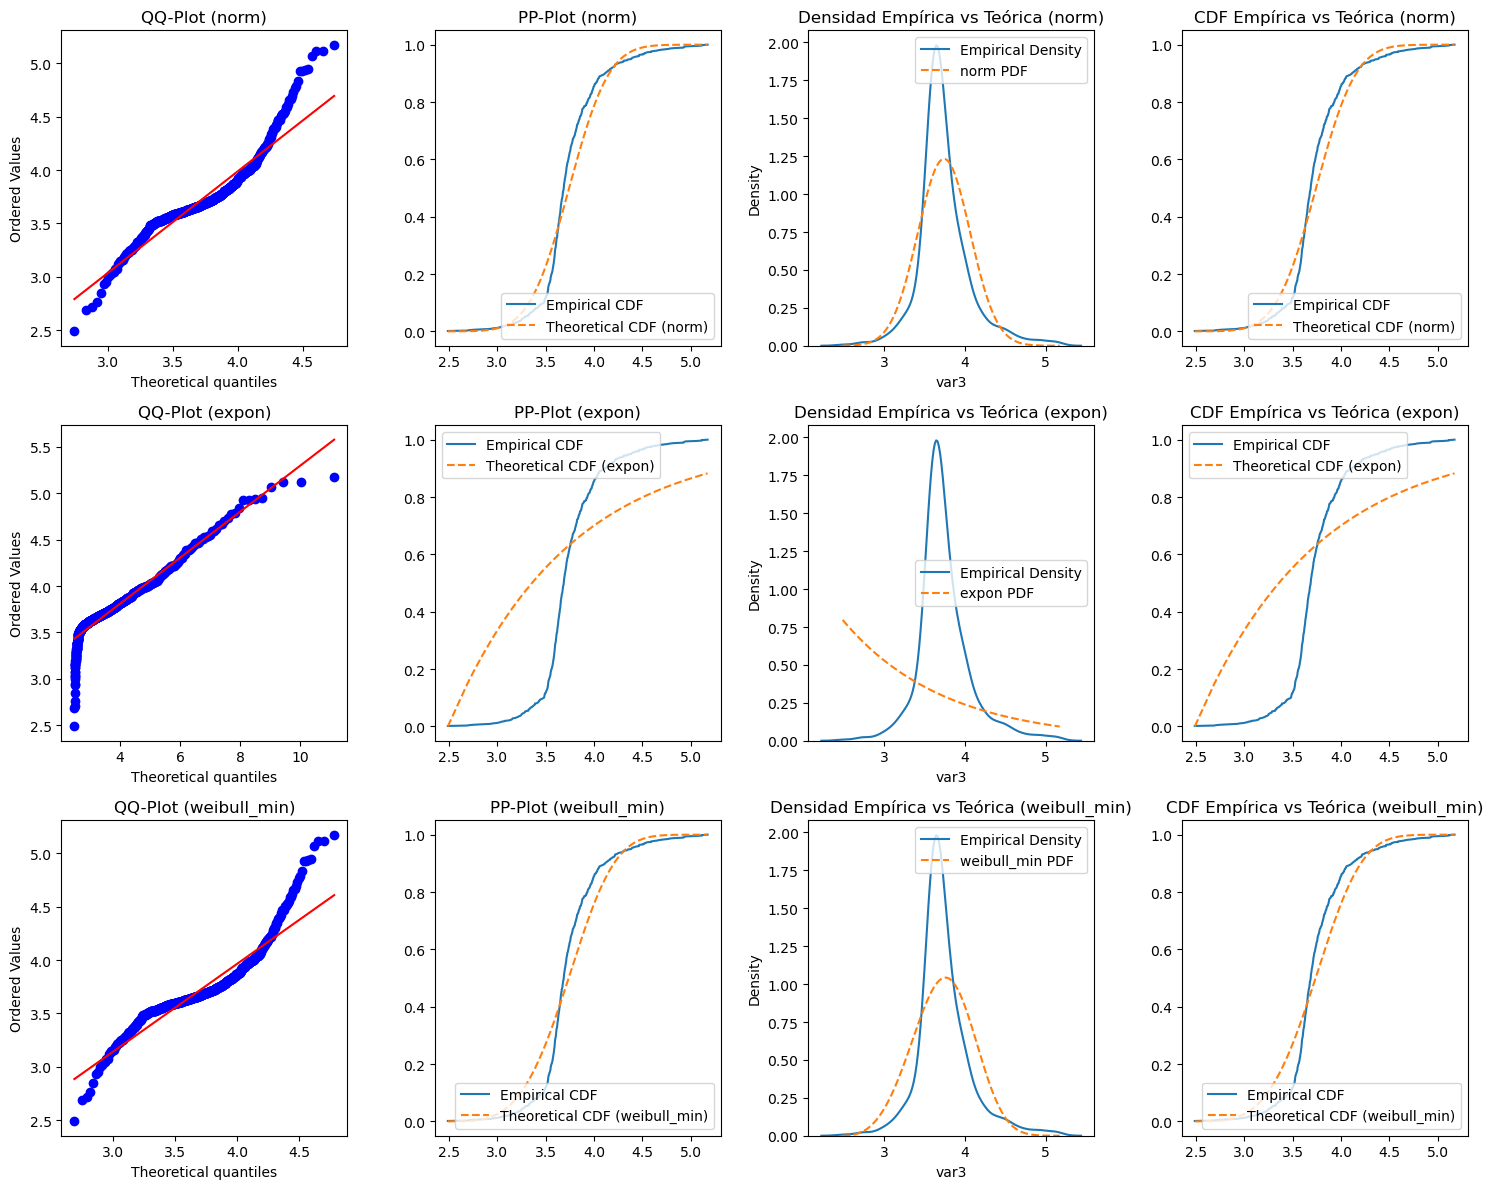

In [5]:
# Definir las distribuciones a ajustar (por ejemplo, normal, exponencial, Weibull)
dist_names = ['norm', 'expon', 'weibull_min']

# Crear una cuadrícula de 3x4 para mostrar todos los gráficos
fig, ax = plt.subplots(3, 4, figsize=(15, 12))

# Graficar para var1
plot_distribution_comparison(data['var1'], 'norm', ax[0, :])
plot_distribution_comparison(data['var1'], 'expon', ax[1, :])
plot_distribution_comparison(data['var1'], 'weibull_min', ax[2, :])

# Graficar para var2
plot_distribution_comparison(data['var2'], 'norm', ax[0, :])
plot_distribution_comparison(data['var2'], 'expon', ax[1, :])
plot_distribution_comparison(data['var2'], 'weibull_min', ax[2, :])

# Graficar para var3
plot_distribution_comparison(data['var3'], 'norm', ax[0, :])
plot_distribution_comparison(data['var3'], 'expon', ax[1, :])
plot_distribution_comparison(data['var3'], 'weibull_min', ax[2, :])

plt.tight_layout()
plt.show()

In [39]:
def get_best_distribution(data, dist_names):
    dist_results = []
    params = {}
    
    for dist_name in dist_names:
        dist = getattr(sps, dist_name)
        param = dist.fit(data)
        params[dist_name] = param
        
        # Kolmogorov-Smirnov test
        D, p = sps.kstest(data, dist_name, args=param)
        print(f'P-value para: {dist_name}: {p}')
        dist_results.append((dist_name, p))
    
    # Mejor distribución
    best_dist, best_p = max(dist_results, key=lambda item: item[1])
    print(f'\nLa mejor distribucion: {best_dist} con un P-value de: {best_p}')
    
    return best_dist, params[best_dist]

In [7]:
dist_names = ['norm', 'expon', 'weibull_min', 'lognorm', 'gamma']
best_dist, best_params = get_best_distribution(data['var1'], dist_names)

P-value para: norm: 1.3896035037080436e-57
P-value para: expon: 4.680781040175771e-99
P-value para: weibull_min: 4.49010919212449e-193
P-value para: lognorm: 2.3065901296622186e-55
P-value para: gamma: 8.329031930962011e-54

La mejor distribucion: gamma con un P-value de: 8.329031930962011e-54


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6554: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)


1. Realizar una prueba de hipótesis de Kolmogorov-Smirnov para constrastar cada distribución contra los datos empíricos.

2. Ordenar de menor a mayor p-value, y seleccionar la de mayor p-value como el modelo que mejor se ajusta.

In [45]:
def realizar_prueba_ks(data, variable, distribuciones, alpha=0.05):
   
    resultados = []
    datos = data[variable].dropna()

    distribuciones_positivas = {
        'expon': True,
        'weibull_min': True,
        'gamma': True,
        'lognorm': True,
        'norm': False,
    }

    for dist_name in distribuciones:
        dist = getattr(sps, dist_name)
        
        requiere_positivos = distribuciones_positivas.get(dist_name, False)
        
        if requiere_positivos:
            datos_filtrados = datos[datos > 0]
        else:
            datos_filtrados = datos

        try:
            params = dist.fit(datos_filtrados)

            estadistico, p_valor = sps.kstest(datos_filtrados, dist_name, args=params)
            rechazo = 'Sí' if p_valor < alpha else 'No'

            resultados.append({
                'Distribución': dist_name,
                'Estadístico KS': estadistico,
                'Valor p': p_valor,
                'Rechazar H₀': rechazo
            })
        except Exception as e:
            resultados.append({
                'Distribución': dist_name,
                'Estadístico KS': np.nan,
                'Valor p': np.nan,
                'Rechazar H₀': f'Error: {e}'
            })

    resultados_df = pd.DataFrame(resultados)
    resultados_df_sorted = resultados_df.sort_values(by='Valor p', ascending=False).reset_index(drop=True)

    return resultados_df_sorted

In [46]:
def graficar_mejor_distribucion(data, variable, distribucion):
    
    dist = getattr(sps, distribucion)
    datos = data[variable].dropna()

    distribuciones_positivas = {
        'expon': True,
        'weibull_min': True,
        'gamma': True,
        'lognorm': True,
        'norm': False,
    }
    requiere_positivos = distribuciones_positivas.get(distribucion, False)
    if requiere_positivos:
        datos = datos[datos > 0]

    params = dist.fit(datos)

    x = np.linspace(datos.min(), datos.max(), 1000)
    pdf_empirical = sps.gaussian_kde(datos)(x)
    pdf_theoretical = dist.pdf(x, *params)

    x_empirical, y_empirical = ecdf(datos)
    y_theoretical = dist.cdf(x_empirical, *params)

    fig, ax = plt.subplots(2, 2, figsize=(15, 12))
    ax = ax.flatten()

    sps.probplot(datos, dist=distribucion, sparams=params, plot=ax[0])
    ax[0].set_title(f'QQ-Plot ({distribucion}) para {variable}')

    ax[1].plot(x_empirical, y_empirical, label='Empirical CDF')
    ax[1].plot(x_empirical, y_theoretical, label=f'Theoretical CDF ({distribucion})', linestyle='--')
    ax[1].legend()
    ax[1].set_title(f'PP-Plot ({distribucion}) para {variable}')

    ax[2].plot(x, pdf_empirical, label='Empirical Density')
    ax[2].plot(x, pdf_theoretical, label=f'{distribucion} PDF', linestyle='--')
    ax[2].legend()
    ax[2].set_title(f'Densidad Empírica vs Teórica ({distribucion}) para {variable}')
    ax[2].set_xlabel('Valor')
    ax[2].set_ylabel('Densidad de Probabilidad')

    ax[3].plot(x_empirical, y_empirical, label='Empirical CDF')
    ax[3].plot(x_empirical, y_theoretical, label=f'Theoretical CDF ({distribucion})', linestyle='--')
    ax[3].legend()
    ax[3].set_title(f'CDF Empírica vs Teórica ({distribucion}) para {variable}')
    ax[3].set_xlabel('Valor')
    ax[3].set_ylabel('Probabilidad Acumulada')

    plt.tight_layout()
    plt.show()



### Resultados para 'var1':

| Distribución   |   Estadístico KS |      Valor p | Rechazar H₀   |
|:---------------|-----------------:|-------------:|:--------------|
| norm           |         0.308165 | 1.3896e-57   | Sí            |
| expon          |         0.394258 | 3.15489e-95  | Sí            |
| weibull_min    |         0.417928 | 1.77827e-107 | Sí            |
| lognorm        |         0.47643  | 1.69736e-141 | Sí            |
| gamma          |         0.518118 | 3.1843e-169  | Sí            |

**Mejor distribución para 'var1':**
Distribución          norm
Estadístico KS    0.308165
Valor p                0.0
Rechazar H₀             Sí
Name: 0, dtype: object


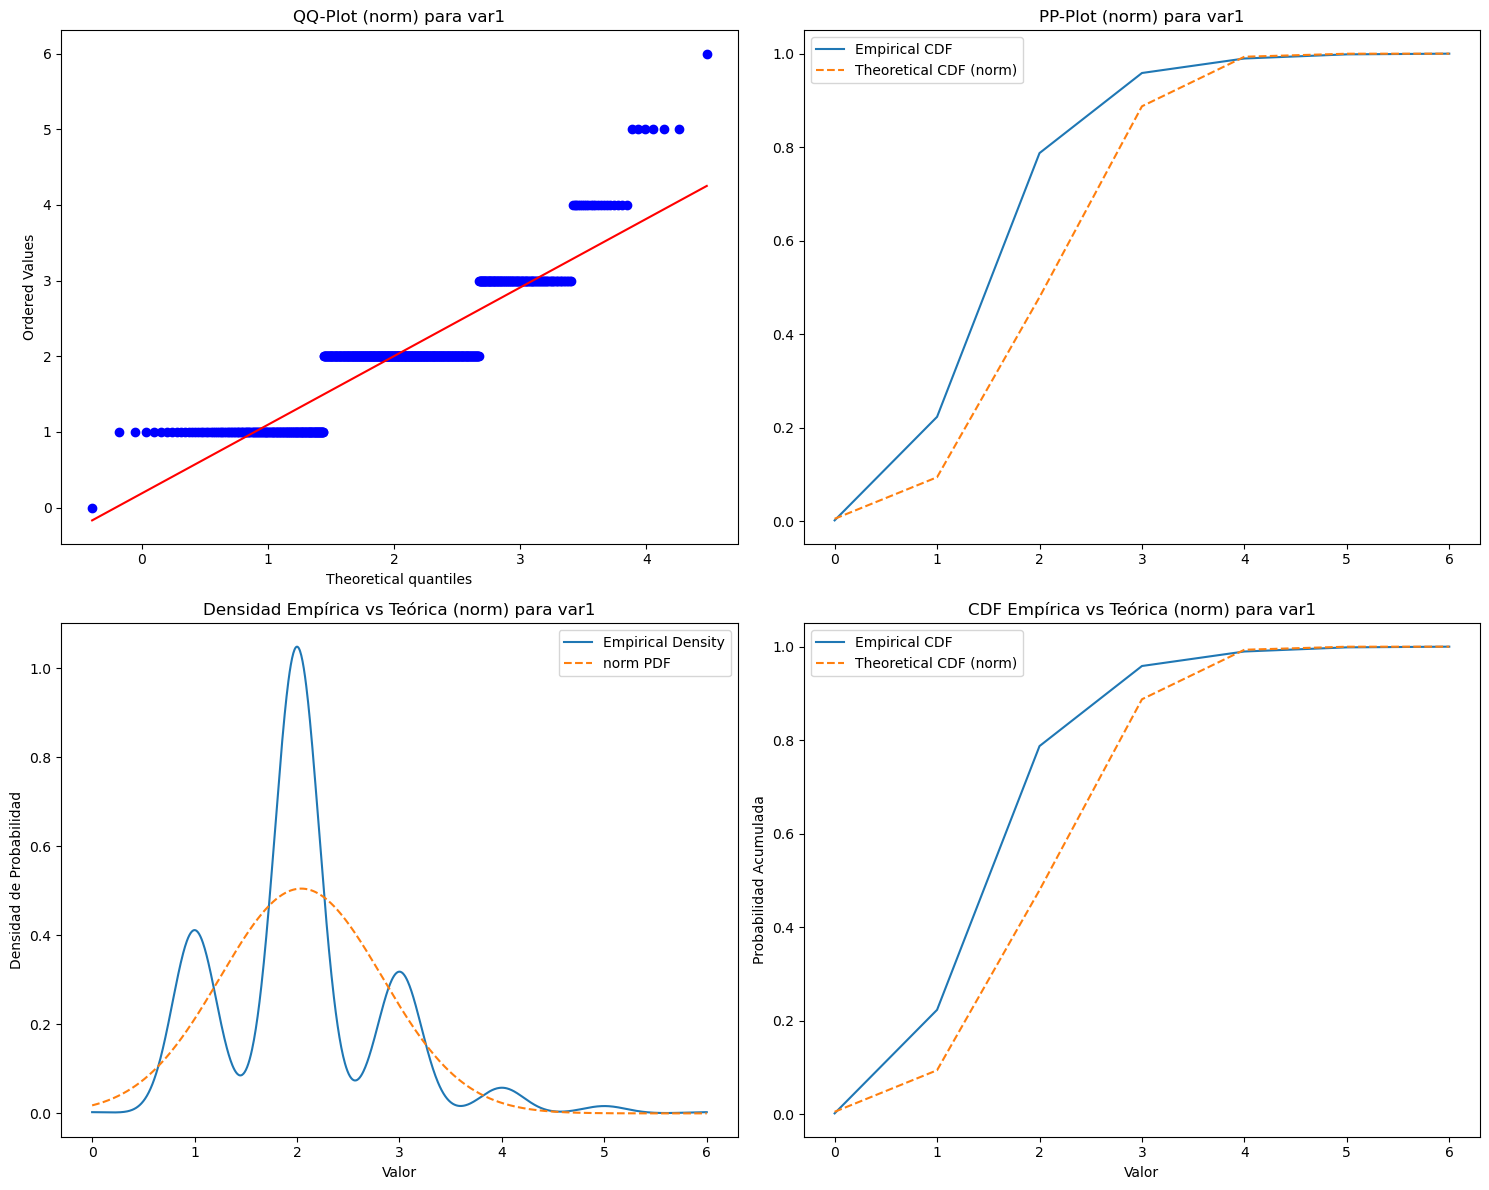


### Resultados para 'var2':

| Distribución   |   Estadístico KS |      Valor p | Rechazar H₀   |
|:---------------|-----------------:|-------------:|:--------------|
| lognorm        |        0.0987164 | 0.00255322   | Sí            |
| gamma          |        0.261715  | 6.46782e-21  | Sí            |
| weibull_min    |        0.438849  | 9.10148e-60  | Sí            |
| norm           |        0.42985   | 3.88655e-114 | Sí            |
| expon          |        0.78118   | 5.81439e-219 | Sí            |

**Mejor distribución para 'var2':**
Distribución       lognorm
Estadístico KS    0.098716
Valor p           0.002553
Rechazar H₀             Sí
Name: 0, dtype: object


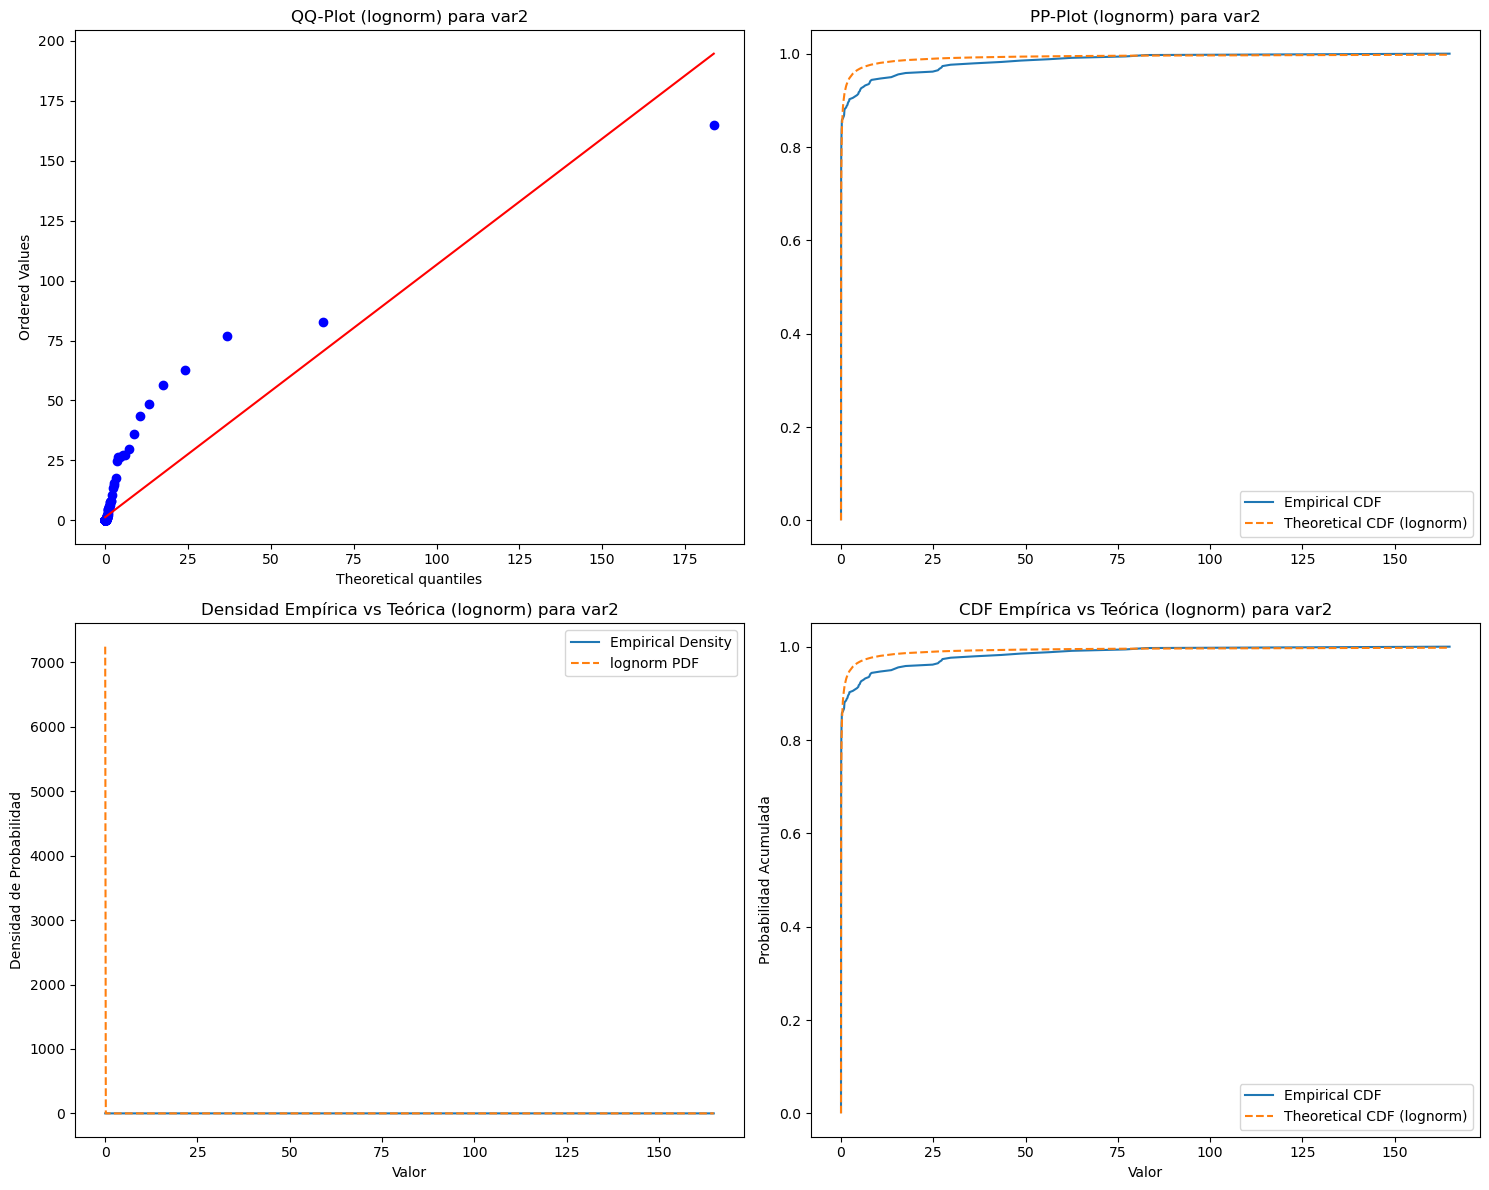


### Resultados para 'var3':

| Distribución   |   Estadístico KS |      Valor p | Rechazar H₀   |
|:---------------|-----------------:|-------------:|:--------------|
| gamma          |         0.1167   | 1.72557e-08  | Sí            |
| lognorm        |         0.116981 | 1.57794e-08  | Sí            |
| norm           |         0.124292 | 1.41966e-09  | Sí            |
| weibull_min    |         0.157728 | 3.53727e-15  | Sí            |
| expon          |         0.448917 | 5.35209e-125 | Sí            |

**Mejor distribución para 'var3':**
Distribución       gamma
Estadístico KS    0.1167
Valor p              0.0
Rechazar H₀           Sí
Name: 0, dtype: object


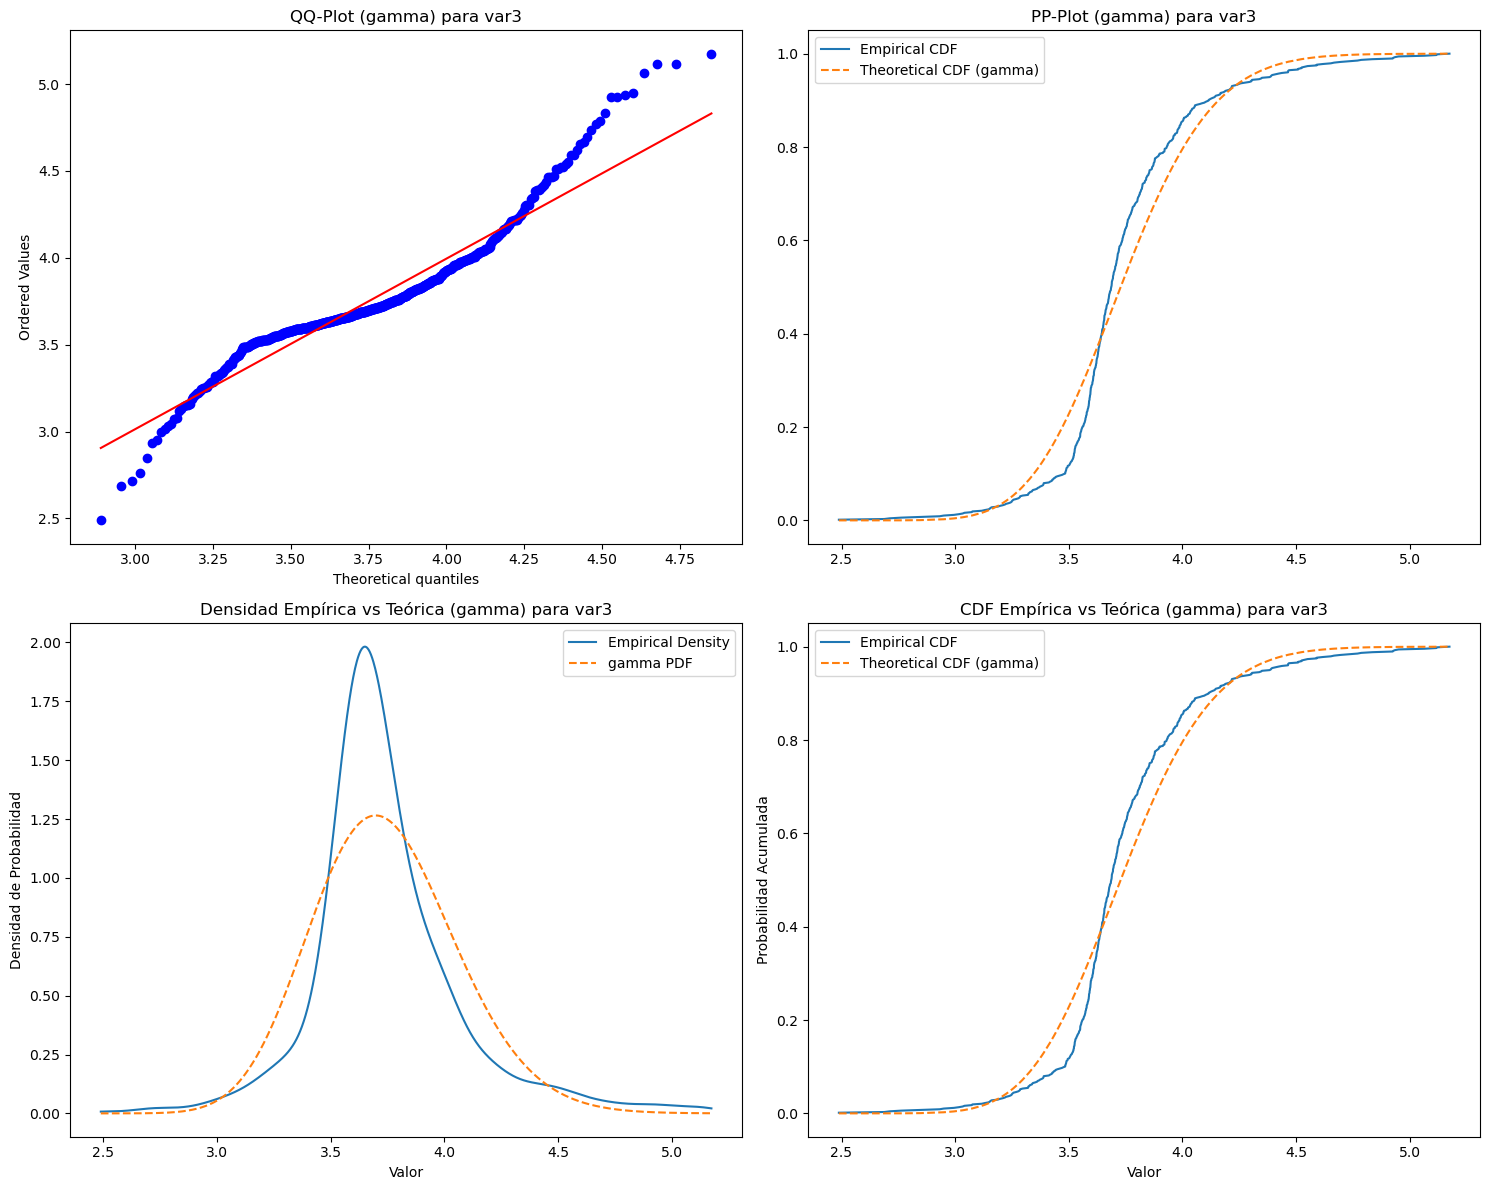


### Resultados para 'var4':

| Distribución   |   Estadístico KS |     Valor p | Rechazar H₀   |
|:---------------|-----------------:|------------:|:--------------|
| weibull_min    |        0.0421449 | 0.175389    | No            |
| gamma          |        0.0474297 | 0.0920854   | No            |
| lognorm        |        0.0607655 | 0.0129141   | Sí            |
| expon          |        0.0656626 | 0.00555951  | Sí            |
| norm           |        0.107979  | 2.49988e-07 | Sí            |

**Mejor distribución para 'var4':**
Distribución      weibull_min
Estadístico KS       0.042145
Valor p              0.175389
Rechazar H₀                No
Name: 0, dtype: object


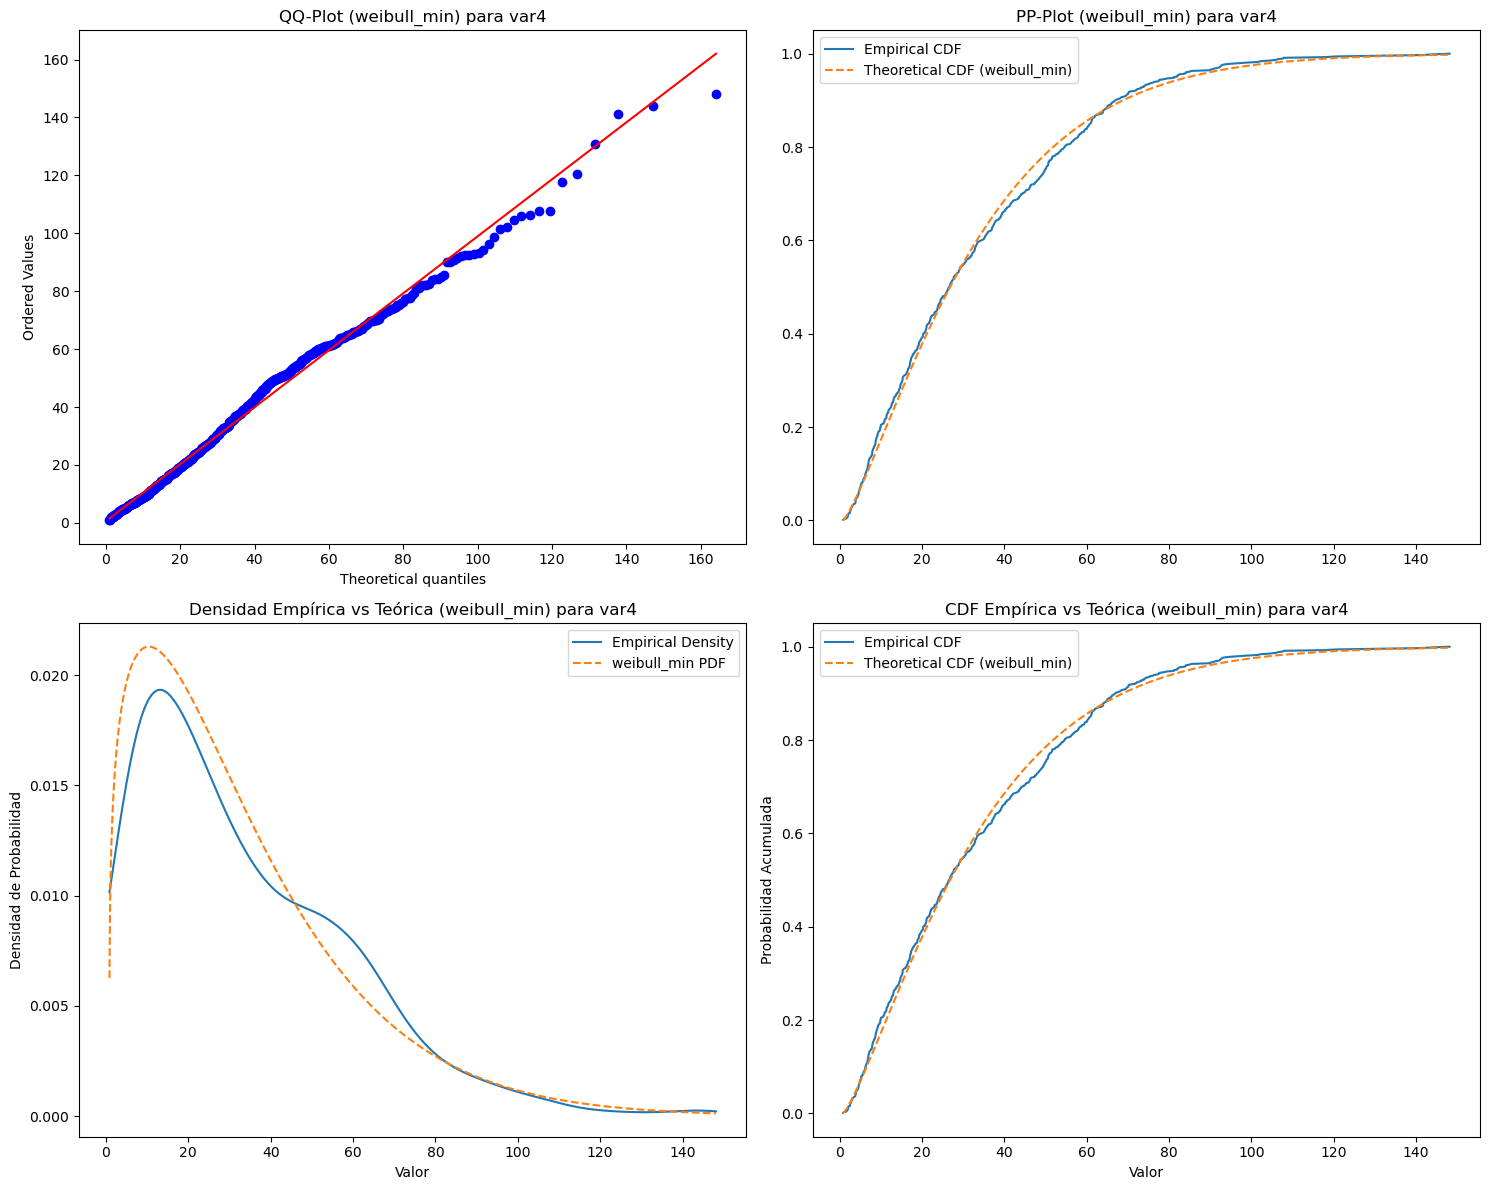


### Resultados para 'var5':

| Distribución   |   Estadístico KS |     Valor p | Rechazar H₀   |
|:---------------|-----------------:|------------:|:--------------|
| lognorm        |        0.0842812 | 0.000124262 | Sí            |
| weibull_min    |        0.252488  | 1.59161e-38 | Sí            |
| norm           |        0.391329  | 6.5852e-94  | Sí            |
| expon          |        0.399806  | 3.6217e-98  | Sí            |
| gamma          |        0.998523  | 0           | Sí            |

**Mejor distribución para 'var5':**
Distribución       lognorm
Estadístico KS    0.084281
Valor p           0.000124
Rechazar H₀             Sí
Name: 0, dtype: object


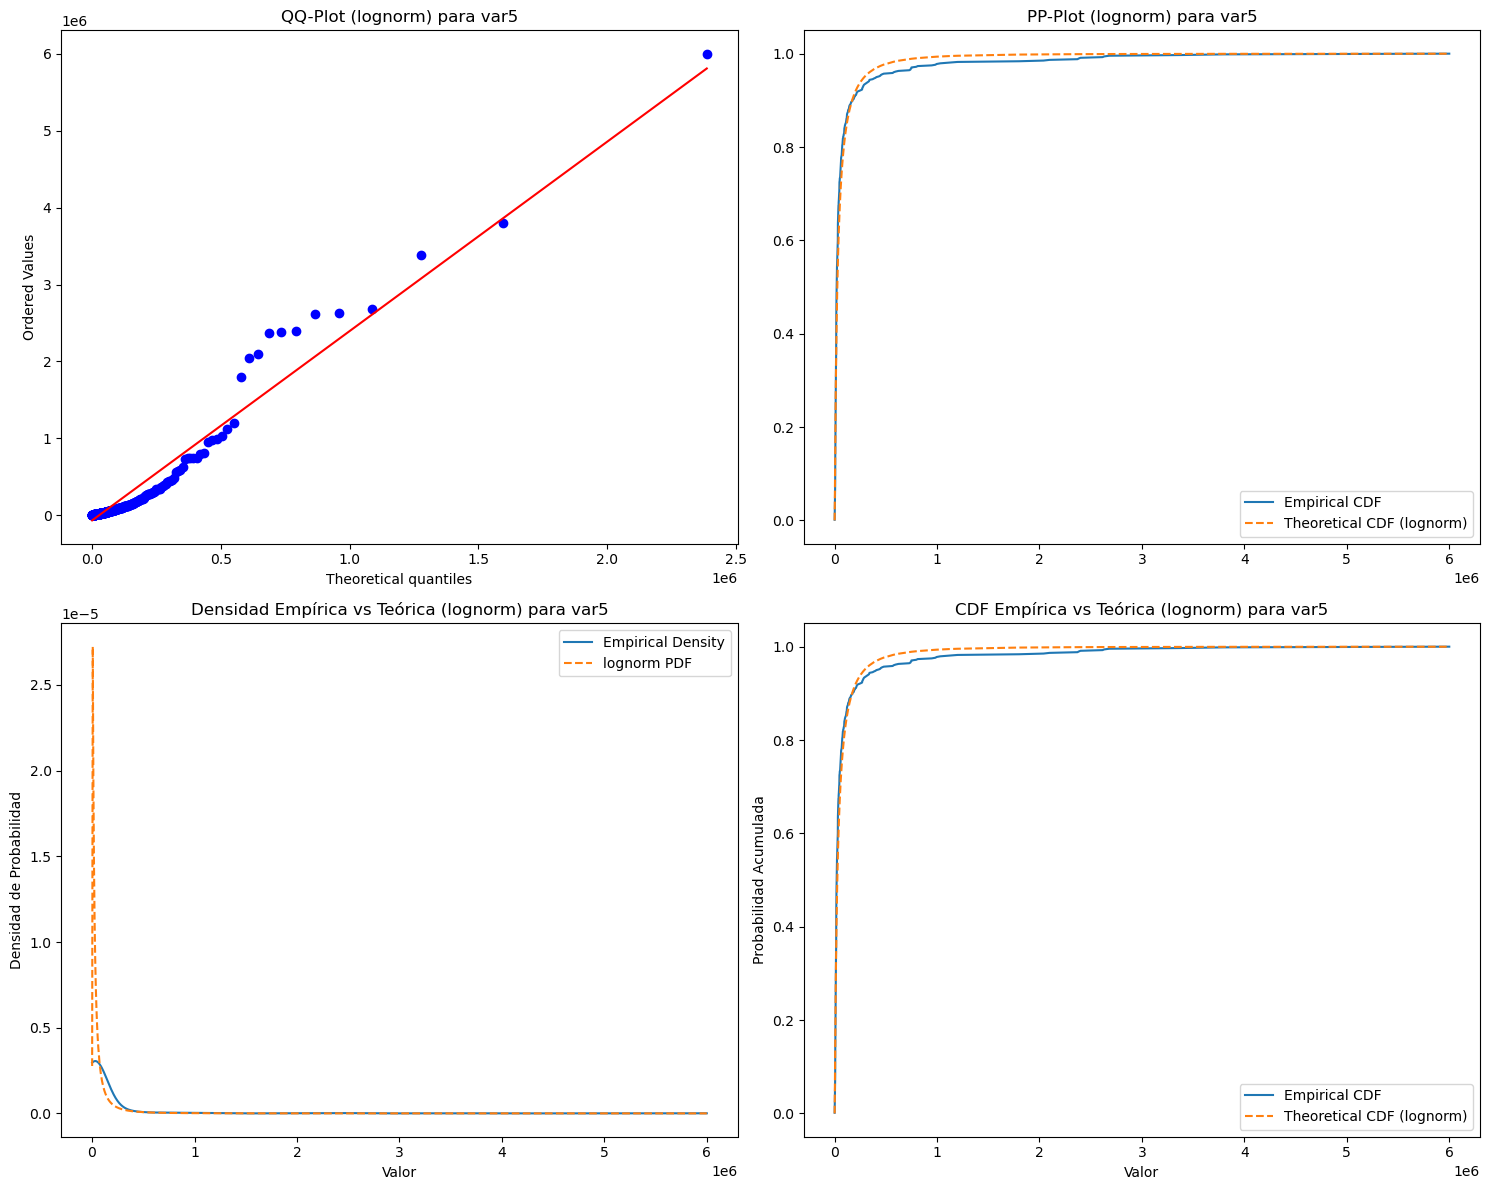

In [47]:
distribuciones = ['norm', 'expon', 'weibull_min', 'lognorm', 'gamma']
variables = ['var1', 'var2', "var3", 'var4', 'var5']
resultados_totales = {}
mejores_distribuciones = {}

for var in variables:
    print(f"\n### Resultados para '{var}':\n")
    
    resultados = realizar_prueba_ks(data, var, distribuciones)
    print(resultados.to_markdown(index=False))
    resultados_totales[var] = resultados

    mejor_dist = resultados.iloc[0]
    mejores_distribuciones[var] = mejor_dist
    print(f"\n**Mejor distribución para '{var}':**")
    print(mejor_dist)
    
    graficar_mejor_distribucion(data, var, mejor_dist['Distribución'])
